# Pipeline
This is where I build my pipeline.

## Idea
1. We will have two categories: Intersection and Address collisions (refer to `exploration.ipynb` for how I came to this conclusion).
2. We will separate the collisons dataset into two subsets, one for each category.

### Extract
1. Intersection and address collisions will have unrelated columns removed.
2. Intersection and address feature sets will also have unrelated columns removed, and will be transformed to contain only `id`, `description` and `geometry` columns.

### Transform
1. Intersection collisions will be mapped to the nearest intersection feature via spatial index, and string match score will be calculated via rapidfuzz
2. Address collisions will be mapped to the nearest address feature via spatial index, and string match score will be calculated via rapidfuzz

### Load
idk what happens now, I guess we just display the results.



In [2]:
# Importing necessary libraries

import geopandas as gpd
import pandas as pd
from shapely.geometry import shape

address_pattern = r'^\d{1,5}\w?\s{0,2}\w+\s?\w+$'
offset_pattern = r'^\d.?\d*\s?[mM]?(etres)?\s?\w{1,5}'

# Function to fix multi point geoms
def to_point(geom):
    if geom.geom_type == "Point":
        return geom
    elif geom.geom_type == "MultiPoint":
        return list(geom.geoms)[0]  # take first point
    else:
        raise ValueError(f"Unsupported geometry type: {geom.geom_type}")


In [3]:
# Loading the collision data
collision_data = pd.read_csv("../data/raw/collisions.csv")

collision_data = collision_data[['collision_id', 'stname1', 'stname2', 'stname3', 'latitude', 'longitude']]

collision_data = gpd.GeoDataFrame(collision_data, geometry=gpd.points_from_xy(collision_data.longitude, collision_data.latitude), crs="EPSG:4326")
collision_data.to_csv("../data/processed/collisions.csv", index=False)
collision_data.count()

collision_id    20455
stname1         20455
stname2         18697
stname3          4659
latitude        20452
longitude       20452
geometry        20455
dtype: int64

In [4]:
# Loading and processing intersection data
from shapely.geometry import shape
import json

# Initialize the intersection data
intersection_data = pd.read_csv('../data/raw/intersections.csv')

# Rename columns for consistency
intersection_data = intersection_data.rename(columns={'INTERSECTION_ID': 'feature_id', 'INTERSECTION_DESC': 'feature_description'})

# Adding type column for use with address data
intersection_data['type'] = 'intersection'

# Extract only necessary columns
intersection_data = intersection_data[['feature_id', 'feature_description', 'type', 'geometry']]

# Filter out rows where description is null or empty
intersection_data = intersection_data[intersection_data['feature_description'].notna() & (intersection_data['feature_description'].str.strip() != '')]

# Convert the geometry from WKT to shapely geometry
intersection_data["geometry"] = intersection_data["geometry"].apply(lambda x: shape(json.loads(x)))
intersection_data = gpd.GeoDataFrame(intersection_data, geometry='geometry', crs="EPSG:4326")

intersection_data['geometry'] = intersection_data['geometry'].apply(lambda x: to_point(x))

intersection_data.to_csv("../data/processed/intersections.csv", index=False)

intersection_data.count()

feature_id             46257
feature_description    46257
type                   46257
geometry               46257
dtype: int64

In [5]:
# Loading and processing address data
from shapely.geometry import shape
import json

address_data = pd.read_csv('../data/raw/addresses.csv')

# Renaming columns for consistency
address_data = address_data.rename(columns={"ADDRESS_POINT_ID": "feature_id", "ADDRESS_FULL": "feature_description"})

# Adding type column for use with intersection data
address_data['type'] = 'address'

# Extracting necessary columns
address_data = address_data[["feature_id", "feature_description", 'type', "geometry"]]

# Filter out rows where description is null or empty
address_data = address_data[address_data['feature_description'].notna() & (address_data['feature_description'].str.strip() != '')]

# Constructing geometry 
address_data["geometry"] = address_data["geometry"].apply(lambda x: shape(json.loads(x)))

address_data = gpd.GeoDataFrame(address_data, geometry="geometry", crs="EPSG:4326")

# Cleaning up multipoint geometry
address_data["geometry"] = address_data["geometry"].apply(lambda x: to_point(x))

address_data.to_csv("../data/processed/addresses.csv")

address_data.count()

/tmp/ipykernel_1869/3179409233.py:5: DtypeWarning: Columns (0: HI_NUM_SUF) have mixed types. Specify dtype option on import or set low_memory=False.
  address_data = pd.read_csv('../data/raw/addresses.csv')


feature_id             525401
feature_description    525401
type                   525401
geometry               525401
dtype: int64

In [6]:
# Separate address collisions from the rest of the collisions

address_collisions = collision_data[collision_data['stname1'].str.match(address_pattern, na=False) | collision_data['stname2'].str.match(address_pattern, na=False)]

address_collisions.count()


collision_id    1286
stname1         1286
stname2          168
stname3          383
latitude        1286
longitude       1286
geometry        1286
dtype: int64

In [7]:
intersection_collisions = collision_data[~collision_data['collision_id'].isin(address_collisions['collision_id'])]

intersection_collisions.count()

collision_id    19169
stname1         19169
stname2         18529
stname3          4276
latitude        19166
longitude       19166
geometry        19169
dtype: int64

In [8]:
# Reproject collisions and features to common CRS

intersection_data = intersection_data.to_crs(epsg=32617)
intersection_collisions = intersection_collisions.to_crs(epsg=32617)

address_data = address_data.to_crs(epsg=32617)
address_collisions = address_collisions.to_crs(epsg=32617)

In [9]:
# Merge collision and feature dataset by distance using spatial index

# Intersections
intersection_merged = gpd.sjoin_nearest(intersection_collisions, intersection_data, distance_col="distance", how="left")

intersection_merged['stname2'] = intersection_merged['stname2'].fillna("")

intersection_merged['collision_description'] = (intersection_merged['stname1'] + " " + intersection_merged['stname2']).str.lower()

intersection_merged['feature_description'] = intersection_merged['feature_description'].str.lower().str.replace("/", "")

# Addresses
address_merged = gpd.sjoin_nearest(address_collisions, address_data, distance_col="distance")

# Filling null values with empty string to help with concat
address_merged['stname2'] = address_merged['stname2'].fillna("")

address_merged['collision_description'] = (address_merged['stname1'] + " " + address_merged["stname2"]).str.lower()

address_merged['feature_description'] = address_merged['feature_description'].str.lower()

intersection_merged.count()

collision_id             19921
stname1                  19921
stname2                  19921
stname3                   4505
latitude                 19918
longitude                19918
geometry                 19921
index_right              19918
feature_id               19918
feature_description      19918
type                     19918
distance                 19918
collision_description    19921
dtype: int64

In [10]:
# Compute string similarity scores

from rapidfuzz import fuzz

# Intersections
intersection_merged['match_score'] = [fuzz.token_sort_ratio(loc, desc) for loc, desc in zip(intersection_merged['collision_description'], intersection_merged['feature_description'])]

# Addresses
address_merged['match_score'] = [fuzz.token_sort_ratio(loc, desc) for loc, desc in zip(address_merged['collision_description'], address_merged['feature_description'])]

In [11]:
# sjoin_nearest creates duplicate rows if there are multiple nearest features for a given collision. We need to pick the feature with the highest string similarity score.

intersection_merged_sorted = intersection_merged.sort_values(by=['match_score'], ascending=False)

intersection_merged = intersection_merged_sorted.loc[~intersection_merged_sorted.index.duplicated(keep="first")]
intersection_merged.count()

address_merged_sorted = address_merged.sort_values(by=['match_score'], ascending=False)

address_merged = address_merged_sorted.loc[~address_merged_sorted.index.duplicated(keep="first")]

address_merged.count()

collision_id             1286
stname1                  1286
stname2                  1286
stname3                   383
latitude                 1286
longitude                1286
geometry                 1286
index_right              1286
feature_id               1286
feature_description      1286
type                     1286
distance                 1286
collision_description    1286
match_score              1286
dtype: int64

In [13]:
# Both intersection and address collision subsets contain a number of collisions with "offsets" in stname3. We will separate these collisions from the rest, extract the number of metres described in the offset, and then subtract this number from the calculated distance.

intersection_offset_collisions = intersection_merged[intersection_merged['stname3'].str.match(offset_pattern, na=False)]

address_offset_collisions = address_merged[address_merged['stname3'].str.match(offset_pattern, na=False)]

print(intersection_offset_collisions["collision_id"].count())

print(address_offset_collisions["collision_id"].count())

4244
376


In [14]:
intersection_offset_collisions.head()

,collision_id,stname1,stname2,stname3,latitude,longitude,geometry,index_right,feature_id,feature_description,type,distance,collision_description,match_score
20454,2025:5001386641,MILL ST,Rolling Mills Rd,6 m South of,43.651755,-79.354764,POINT (632675.305 4834510.303),37805.0,30043794.0,rolling mills rd mill st,intersection,41.286418,mill st rolling mills rd,100.0
20427,2025:5001386641,MILL ST,Rolling Mills Rd,6 m South of,43.651755,-79.354764,POINT (632675.305 4834510.303),37805.0,30043794.0,rolling mills rd mill st,intersection,41.286418,mill st rolling mills rd,100.0
20426,2025:5001386641,MILL ST,Rolling Mills Rd,6 m South of,43.651755,-79.354764,POINT (632675.305 4834510.303),37805.0,30043794.0,rolling mills rd mill st,intersection,41.286418,mill st rolling mills rd,100.0
20424,2025:5000721646,LAKE SHORE BLVD W,FIFTH ST,5 m East of,43.601263,-79.503003,POINT (620821.944 4828676.235),2920.0,13470434.0,lake shore blvd w fifth st,intersection,2.221683,lake shore blvd w fifth st,100.0
20423,2025:5000721646,LAKE SHORE BLVD W,FIFTH ST,5 m East of,43.601263,-79.503003,POINT (620821.944 4828676.235),2920.0,13470434.0,lake shore blvd w fifth st,intersection,2.221683,lake shore blvd w fifth st,100.0


In [15]:
address_offset_collisions.head()

,collision_id,stname1,stname2,stname3,latitude,longitude,geometry,index_right,feature_id,feature_description,type,distance,collision_description,match_score
13919,2017:7001556385,215 LONSDALE RD,,51 m West of,43.690565,-79.403645,POINT (628650.436 4838743.689),479287,30113492,215 lonsdale rd,address,27.86922,215 lonsdale rd,100.0
13774,2017:7001269132,538 MCLEVIN AVE,,107 m East of,43.810434,-79.216625,POINT (643435.923 4852364.115),158397,361784,538 mclevin ave,address,36.82968,538 mclevin ave,100.0
13773,2017:7001269132,538 MCLEVIN AVE,,107 m East of,43.810434,-79.216625,POINT (643435.923 4852364.115),158397,361784,538 mclevin ave,address,36.82968,538 mclevin ave,100.0
13772,2017:7001269132,538 MCLEVIN AVE,,107 m East of,43.810434,-79.216625,POINT (643435.923 4852364.115),158397,361784,538 mclevin ave,address,36.82968,538 mclevin ave,100.0
13771,2017:7001269132,538 MCLEVIN AVE,,107 m East of,43.810434,-79.216625,POINT (643435.923 4852364.115),158397,361784,538 mclevin ave,address,36.82968,538 mclevin ave,100.0


In [33]:
intersection_offset_collisions["offset"] = intersection_offset_collisions['stname3'].str.extract(r"(\d+)")
intersection_offset_collisions["offset"] = pd.to_numeric(intersection_offset_collisions["offset"], errors="coerce")
intersection_offset_collisions.head()
intersection_offset_collisions["offset"].isna().count() // intersection_offset_collisions["offset"].count()

np.int64(1)

In [38]:
address_offset_collisions["offset"] = address_offset_collisions['stname3'].str.extract(r"(\d+)")
address_offset_collisions["offset"] = pd.to_numeric(address_offset_collisions["offset"], errors="coerce")
address_offset_collisions.head()
address_offset_collisions['offset'].isna().count() // address_offset_collisions['offset'].count()

np.int64(1)

<Axes: >

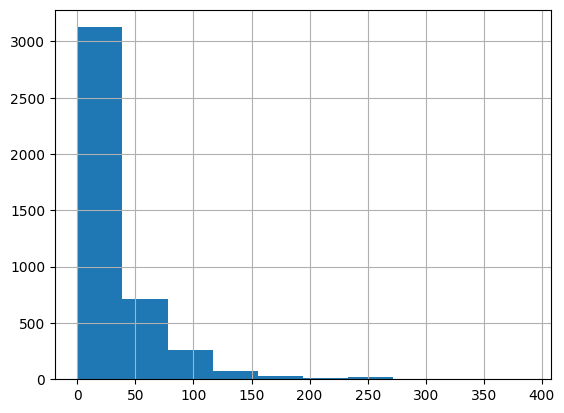

In [40]:
intersection_offset_collisions["distance"] = abs(intersection_offset_collisions["distance"] - intersection_offset_collisions["offset"])
intersection_offset_collisions.head()

intersection_offset_collisions["distance"].hist()

<Axes: >

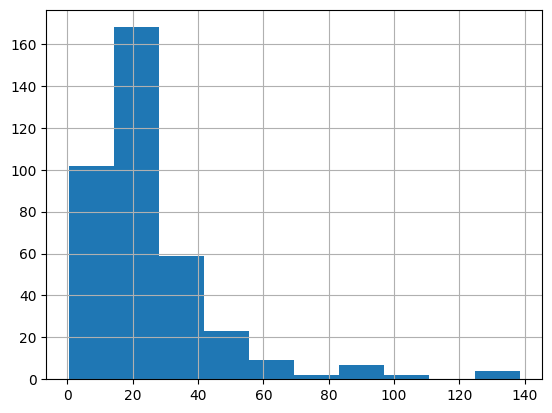

In [41]:
address_offset_collisions["distance"] = abs(address_offset_collisions["distance"] - address_offset_collisions["offset"])
address_offset_collisions.head()

address_offset_collisions["distance"].hist()

In [42]:
address_offset_collisions[address_offset_collisions['distance'] >= 80]

,collision_id,stname1,stname2,stname3,latitude,longitude,geometry,index_right,feature_id,feature_description,type,distance,collision_description,match_score,offset
16240,2019:9002496688,2901 JANE ST,,3 m East of,43.753241,-79.516652,POINT (619418.5 4845535.609),520398,10093092,2901 jane st,address,88.882078,2901 jane st,100.000000,3
16239,2019:9002496688,2901 JANE ST,,3 m East of,43.753241,-79.516652,POINT (619418.5 4845535.609),520398,10093092,2901 jane st,address,88.882078,2901 jane st,100.000000,3
11947,2015:5001684106,939 PROGRESS AVE,,4 m North of,43.783899,-79.231899,POINT (642270.388 4849390.609),468625,13503974,940 progress ave,address,88.534863,939 progress ave,87.500000,4
11948,2015:5001684106,939 PROGRESS AVE,,4 m North of,43.783899,-79.231899,POINT (642270.388 4849390.609),468625,13503974,940 progress ave,address,88.534863,939 progress ave,87.500000,4
14369,2018:8000340465,931 PROGRESS AVE,,5 m West of,43.783800,-79.231838,POINT (642275.528 4849379.747),468625,13503974,940 progress ave,address,93.415043,931 progress ave,87.500000,5
14368,2018:8000340465,931 PROGRESS AVE,,5 m West of,43.783800,-79.231838,POINT (642275.528 4849379.747),468625,13503974,940 progress ave,address,93.415043,931 progress ave,87.500000,5
14367,2018:8000340465,931 PROGRESS AVE,,5 m West of,43.783800,-79.231838,POINT (642275.528 4849379.747),468625,13503974,940 progress ave,address,93.415043,931 progress ave,87.500000,5
20074,2025:5001654956,700 ARROW RD,ARROW RD,2 m South of,43.745656,-79.529497,POINT (618399.346 4844674.779),261449,30026370,124 arrow rd,address,138.457802,700 arrow rd arrow rd,54.545455,2
20072,2025:5001654956,700 ARROW RD,ARROW RD,2 m South of,43.745656,-79.529497,POINT (618399.346 4844674.779),261449,30026370,124 arrow rd,address,138.457802,700 arrow rd arrow rd,54.545455,2
20075,2025:5001654956,700 ARROW RD,ARROW RD,2 m South of,43.745656,-79.529497,POINT (618399.346 4844674.779),261449,30026370,124 arrow rd,address,138.457802,700 arrow rd arrow rd,54.545455,2
